In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
file_path = "titanic.csv"
df = pd.read_csv("C:\\Users\\Antony\\internship\\AI\\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [5]:
missing = df.isnull().sum()
missing

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

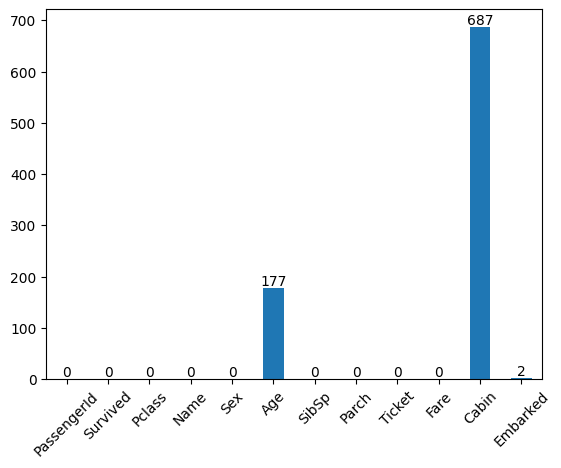

In [6]:
plt.figure()
missing.plot(kind='bar')
plt.xticks(rotation=45)

for i, v in enumerate(missing):
    plt.text(i, v+5, str(v), ha='center')

plt.show()

In [7]:
df = df.drop(columns=['Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

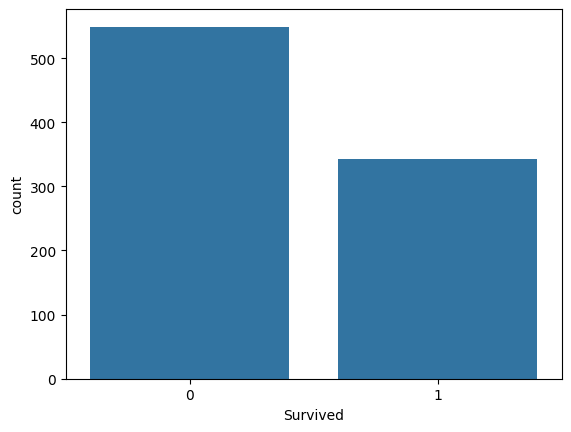

In [8]:
sns.countplot(x='Survived', data=df)
plt.show()

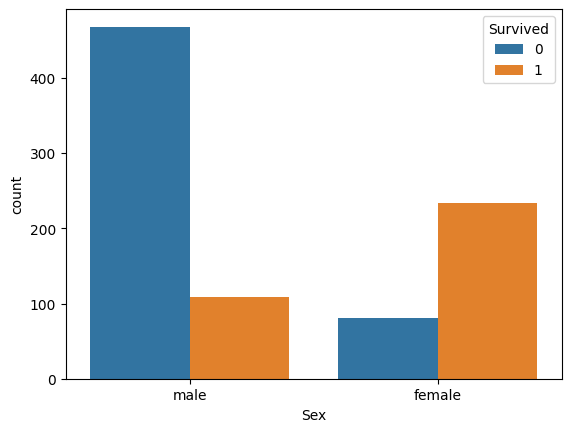

In [9]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

In [10]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

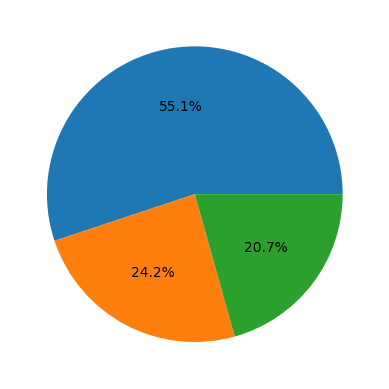

In [11]:
plt.pie(df['Pclass'].value_counts(), autopct='%1.1f%%')
plt.show()

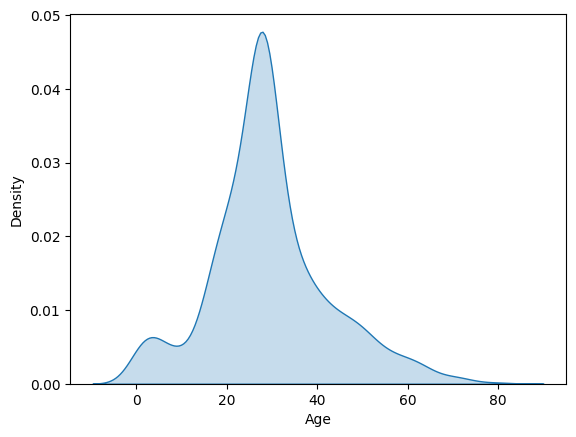

In [12]:
sns.kdeplot(df['Age'], fill=True)
plt.show()

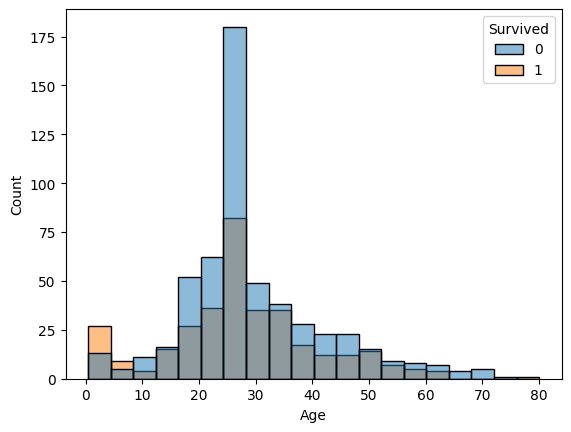

In [13]:
sns.histplot(data=df, x='Age', hue='Survived', bins=20)
plt.show()

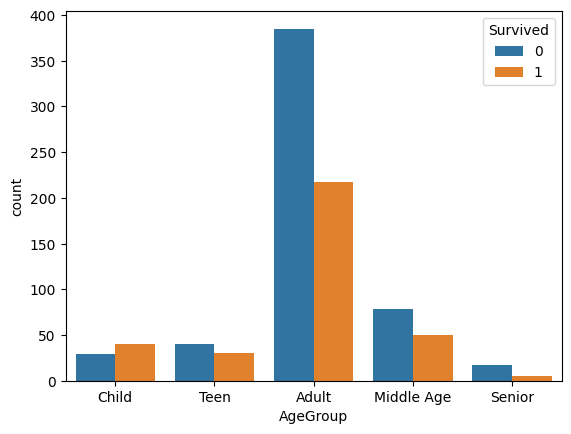

In [14]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,40,60,100],
labels=['Child','Teen','Adult','Middle Age','Senior'])

sns.countplot(x='AgeGroup', hue='Survived', data=df)
plt.show()